# Большая модель: ai-forever/ruBert-large

**Модель:** `ai-forever/ruBert-large` | **Параметры:** ~560M  
**Устройство:** RTX 2070 Super (CUDA) | **Датасет:** RuReviews 90K

> **Оптимизации памяти:** gradient checkpointing + gradient accumulation (ACCUM=4) + fp16 AMP.  
> Эффективный batch = 8×4 = 32. Модель занимает ~6–8 ГБ VRAM из 8 ГБ.

## 1. Установка зависимостей

In [7]:
# Установка PyTorch с поддержкой CUDA 12.1 (RTX 2070 Super)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install transformers==4.40.0 scikit-learn pandas matplotlib seaborn tqdm psutil


Looking in indexes: https://download.pytorch.org/whl/cu121



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Импорты и конфигурация

In [8]:
import os, time, random, re, warnings, psutil
# CUDA для RTX 2070 Super
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)

# RTX 2070 Super: CUDA → иначе CPU
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.backends.cudnn.benchmark = True  # авто-тюнинг CUDA ядер: +5–15% скорости
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
print(f"Устройство: {DEVICE}")

MODEL_NAME   = "ai-forever/ruBert-large"
MAX_LENGTH   = 128       # 128 токенов хватает для большинства отзывов; attention O(n²) → 2–3x быстрее чем 256
BATCH_SIZE   = 16        # удвоен: GPU утилизируется плотнее (AMP+checkpointing влезает в 8 ГБ)
EPOCHS       = 3
LR           = 1e-5
WARMUP_RATIO = 0.06
ACCUM_STEPS  = 2         # эффективный batch = 16×2 = 32 (как раньше 8×4)
DATA_PATH    = "data/rureviews.csv"
SAVE_DIR     = "./saved_model"
LABEL2ID     = {"negative": 0, "neautral": 1, "positive": 2}
ID2LABEL     = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS   = 3
CLASS_NAMES  = ["negative", "neautral", "positive"]

GPU: NVIDIA GeForce RTX 2070 SUPER
Устройство: cuda


## 3. Загрузка и EDA

In [9]:
df = pd.read_csv(DATA_PATH, sep="\t")
print(f"Размер: {df.shape}")
display(df.head())

Размер: (90000, 2)


,review,sentiment
0,качество плохое пошив ужасный (горловина напер...,negative
1,"Товар отдали другому человеку, я не получила п...",negative
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"Кофточка голая синтетика, носить не возможно.",negative


sentiment
negative    30000
neautral    30000
positive    30000
Name: count, dtype: int64


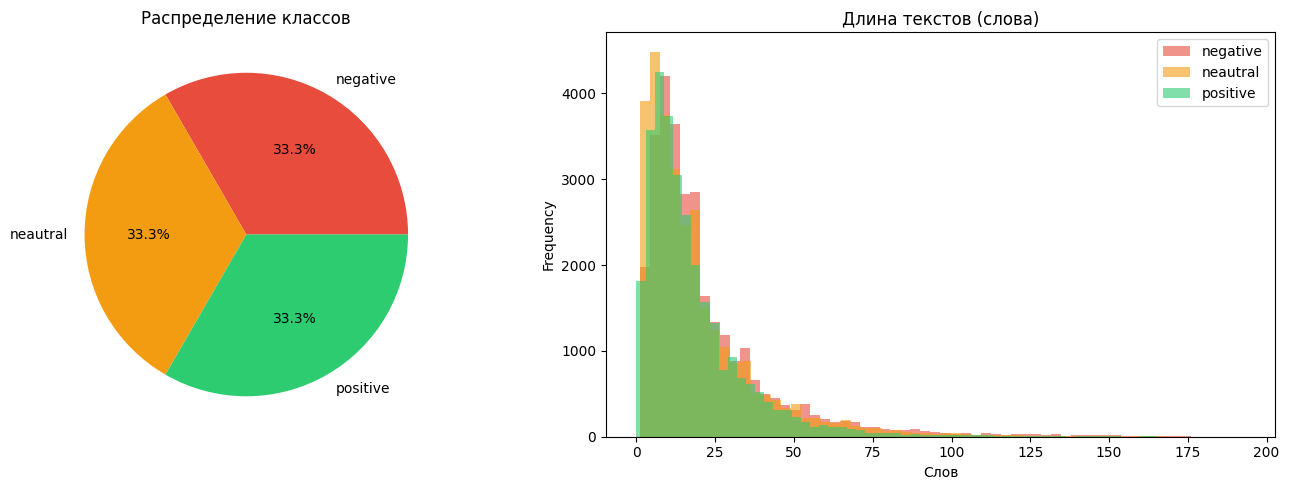

count    90000.000000
mean        20.011144
std         19.885001
min          0.000000
25%          8.000000
50%         14.000000
75%         25.000000
max        193.000000
Name: text_len, dtype: float64


In [10]:
print(df["sentiment"].value_counts())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["sentiment"].value_counts().plot.pie(ax=axes[0], autopct="%1.1f%%",
    colors=["#e74c3c","#f39c12","#2ecc71"])
axes[0].set_title("Распределение классов"); axes[0].set_ylabel("")
df["text_len"] = df["review"].str.split().str.len()
for lbl, clr in zip(CLASS_NAMES, ["#e74c3c","#f39c12","#2ecc71"]):
    df[df["sentiment"]==lbl]["text_len"].plot.hist(ax=axes[1], bins=60, alpha=0.6, color=clr, label=lbl)
axes[1].set_title("Длина текстов (слова)"); axes[1].set_xlabel("Слов"); axes[1].legend()
plt.tight_layout(); plt.show()
print(df["text_len"].describe())

## 4. Предобработка и разбивка

In [11]:
def clean_text(t):
    t = re.sub(r"http\S+", "", str(t))
    return re.sub(r"\s+", " ", t).strip()

df["review_clean"] = df["review"].apply(clean_text)
df["label"]        = df["sentiment"].map(LABEL2ID)
df = df.dropna(subset=["review_clean","label"]).reset_index(drop=True)
df["label"] = df["label"].astype(int)
print(f"Записей: {len(df)}")

# tolist() вместо .values — избегает проблем sklearn с numpy object array
X = df["review_clean"].tolist()
y = df["label"].tolist()

X_train,X_tmp,y_train,y_tmp = train_test_split(X,y,test_size=0.2,random_state=SEED,stratify=y)
X_val,X_test,y_val,y_test   = train_test_split(X_tmp,y_tmp,test_size=0.5,random_state=SEED,stratify=y_tmp)
print(f"Train:{len(X_train)} Val:{len(X_val)} Test:{len(X_test)}")

Записей: 90000
Train:72000 Val:9000 Test:9000


## 5. Токенизация и DataLoader

In [12]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Предтокенизация: токенизируем ВСЁ разом (batch tokenizer в 10–50x быстрее поштучного)
# После этого __getitem__ — просто индексация по тензорам, GPU не ждёт CPU
def encode_all(texts, labels):
    enc = tokenizer(texts, max_length=MAX_LENGTH, padding="max_length",
                    truncation=True, return_tensors="pt")
    return torch.utils.data.TensorDataset(
        enc["input_ids"], enc["attention_mask"],
        torch.tensor(labels, dtype=torch.long)
    )

print("Токенизация train..."); train_ds = encode_all(X_train, y_train)
print("Токенизация val...");   val_ds   = encode_all(X_val,   y_val)
print("Токенизация test...");  test_ds  = encode_all(X_test,  y_test)
print("Готово!")

# pin_memory=True — ускоряет CPU→GPU передачу
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f"Батчей — train:{len(train_loader)} val:{len(val_loader)} test:{len(test_loader)}")

Токенизация train...
Токенизация val...
Токенизация test...
Готово!
Батчей — train:4500 val:563 test:563


## 6. Дообучение

- **Gradient checkpointing** — пересчитывает активации при backprop, экономит ~40% памяти
- **Gradient accumulation** (ACCUM_STEPS=4) — накапливает градиенты перед шагом оптимизатора


In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID
).to(DEVICE)

# Gradient checkpointing: экономит ~40% памяти ценой ~20% скорости
model.gradient_checkpointing_enable()

total_params = sum(p.numel() for p in model.parameters())
print(f"Параметров: {total_params:,}")

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scaler    = torch.cuda.amp.GradScaler(enabled=DEVICE.type=="cuda")  # AMP для экономии fp16

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Параметров: 426,911,747


In [14]:
total_steps = (len(train_loader) // ACCUM_STEPS) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(total_steps*WARMUP_RATIO),
    num_training_steps=total_steps)
criterion = nn.CrossEntropyLoss()

### Тест на примерах ДО обучения

In [15]:
SAMPLE_REVIEWS = [
    ("Товар просто ужасный, развалился на второй день. Деньги выброшены на ветер!", "negative"),
    ("Пришло быстро, но качество так себе. Ожидал большего за эти деньги.", "neautral"),
    ("Отличный продукт! Заказываю уже третий раз, всегда доволен. Рекомендую всем!", "positive"),
    ("Совсем не то, что на картинке. Цвет другой, размер не совпадает.", "negative"),
    ("Нормально, ничего особенного. Пользуюсь, пока не сломалось.", "neautral"),
    ("Превзошло все ожидания! Качество на высоте, доставка молниеносная.", "positive"),
]

SEP = "=" * 60

def test_samples(mdl, label=""):
    mdl.eval()
    print(f"\n{SEP}")
    print(f"  {label}")
    print(SEP)
    results = []
    for text, true_label in SAMPLE_REVIEWS:
        enc = tokenizer(text, max_length=MAX_LENGTH, padding="max_length",
                        truncation=True, return_tensors="pt")
        with torch.no_grad():
            logits = mdl(input_ids=enc["input_ids"].to(DEVICE),
                         attention_mask=enc["attention_mask"].to(DEVICE)).logits
        probs = torch.softmax(logits, -1).cpu().squeeze().tolist()
        pred  = ID2LABEL[int(torch.tensor(probs).argmax())]
        conf  = max(probs) * 100
        status = "OK   " if pred == true_label else "WRONG"
        print(f"[{status}] {text[:65]}")
        print(f"        Истина: {true_label:<10} | Предсказано: {pred:<10} | Уверенность: {conf:.1f}%")
        print()
        results.append({"text": text, "true": true_label, "pred": pred,
                        "conf": conf, "correct": pred == true_label})
    n_correct = sum(r["correct"] for r in results)
    print(f"  Точность на примерах: {n_correct}/{len(results)} ({n_correct/len(results)*100:.0f}%)")
    return results

In [16]:
# Тест ДО обучения — голая предобученная модель, без fine-tuning
results_before = test_samples(model, label="ДО ОБУЧЕНИЯ (предобученная модель)")


  ДО ОБУЧЕНИЯ (предобученная модель)
[OK   ] Товар просто ужасный, развалился на второй день. Деньги выброшены
        Истина: negative   | Предсказано: negative   | Уверенность: 39.2%

[WRONG] Пришло быстро, но качество так себе. Ожидал большего за эти деньг
        Истина: neautral   | Предсказано: negative   | Уверенность: 40.9%

[WRONG] Отличный продукт! Заказываю уже третий раз, всегда доволен. Реком
        Истина: positive   | Предсказано: negative   | Уверенность: 41.9%

[OK   ] Совсем не то, что на картинке. Цвет другой, размер не совпадает.
        Истина: negative   | Предсказано: negative   | Уверенность: 41.1%

[WRONG] Нормально, ничего особенного. Пользуюсь, пока не сломалось.
        Истина: neautral   | Предсказано: negative   | Уверенность: 43.4%

[OK   ] Превзошло все ожидания! Качество на высоте, доставка молниеносная
        Истина: positive   | Предсказано: positive   | Уверенность: 41.0%

  Точность на примерах: 3/6 (50%)


In [17]:
# Gradient accumulation + AMP fp16:
# - накапливаем градиенты ACCUM_STEPS батчей → эффективный batch = 32
# - autocast + scaler → fp16 снижает VRAM и ускоряет обучение на CUDA
def train_epoch(model, loader):
    model.train(); optimizer.zero_grad()
    loss_sum, correct, n = 0.0, 0, 0
    for step, (ids, mask, lbl) in enumerate(tqdm(loader, desc="train", leave=False)):
        ids  = ids.to(DEVICE, non_blocking=True)
        mask = mask.to(DEVICE, non_blocking=True)
        lbl  = lbl.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE.type=="cuda"):  # fp16 AMP
            out  = model(input_ids=ids, attention_mask=mask)
            loss = criterion(out.logits, lbl) / ACCUM_STEPS
        scaler.scale(loss).backward()
        if (step+1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            scheduler.step(); optimizer.zero_grad()
        loss_sum += loss.item()*ACCUM_STEPS*lbl.size(0)
        correct  += (out.logits.argmax(-1)==lbl).sum().item()
        n        += lbl.size(0)
    return loss_sum/n, correct/n

# inference_mode — быстрее no_grad: полностью отключает autograd
@torch.inference_mode()
def eval_epoch(model, loader):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    preds_all, labels_all = [], []
    for ids, mask, lbl in tqdm(loader, desc="eval", leave=False):
        ids  = ids.to(DEVICE, non_blocking=True)
        mask = mask.to(DEVICE, non_blocking=True)
        lbl  = lbl.to(DEVICE, non_blocking=True)
        out  = model(input_ids=ids, attention_mask=mask)
        loss_sum += criterion(out.logits, lbl).item()*lbl.size(0)
        p = out.logits.argmax(-1)
        correct  += (p==lbl).sum().item(); n += lbl.size(0)
        preds_all.extend(p.cpu().tolist()); labels_all.extend(lbl.cpu().tolist())
    return loss_sum/n, correct/n, f1_score(labels_all, preds_all, average="macro")

In [18]:
history = {k:[] for k in ["tl","vl","ta","va","vf1"]}
best_f1 = 0.0
os.makedirs(SAVE_DIR, exist_ok=True)

for epoch in range(1, EPOCHS+1):
    tl, ta = train_epoch(model, train_loader)
    vl, va, vf1 = eval_epoch(model, val_loader)
    for k,v in zip(["tl","vl","ta","va","vf1"],[tl,vl,ta,va,vf1]):
        history[k].append(v)
    print(f"Epoch {epoch}/{EPOCHS} | Train loss={tl:.4f} acc={ta:.4f} | Val loss={vl:.4f} acc={va:.4f} F1={vf1:.4f}")
    if vf1 > best_f1:
        best_f1 = vf1
        model.save_pretrained(SAVE_DIR); tokenizer.save_pretrained(SAVE_DIR)
        print(f"  -> Сохранена лучшая модель F1={best_f1:.4f}")

Epoch 1/3 | Train loss=0.5690 acc=0.7421 | Val loss=0.4868 acc=0.7843 F1=0.7848
  -> Сохранена лучшая модель F1=0.7848


Epoch 2/3 | Train loss=0.4440 acc=0.8077 | Val loss=0.4843 acc=0.7921 F1=0.7934
  -> Сохранена лучшая модель F1=0.7934


Epoch 3/3 | Train loss=0.3648 acc=0.8475 | Val loss=0.5222 acc=0.7889 F1=0.7901


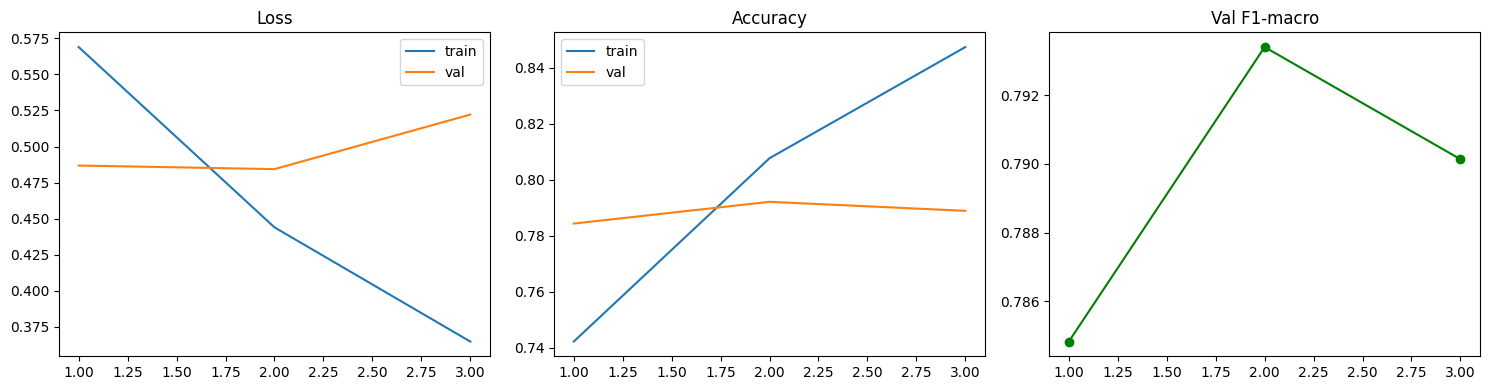

In [19]:
ep = range(1, EPOCHS+1)
fig, ax = plt.subplots(1, 3, figsize=(15,4))
ax[0].plot(ep, history["tl"], label="train"); ax[0].plot(ep, history["vl"], label="val")
ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(ep, history["ta"], label="train"); ax[1].plot(ep, history["va"], label="val")
ax[1].set_title("Accuracy"); ax[1].legend()
ax[2].plot(ep, history["vf1"], marker="o", color="green")
ax[2].set_title("Val F1-macro")
plt.tight_layout(); plt.show()

## 7. Метрики на тестовой выборке

In [20]:
model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(DEVICE)
model.eval(); print("Лучшая модель загружена")

Лучшая модель загружена


### Тест на примерах ПОСЛЕ обучения

In [21]:
# Тест ПОСЛЕ обучения — дообученная на RuReviews модель
results_after = test_samples(model, label="ПОСЛЕ ОБУЧЕНИЯ (дообученная на RuReviews)")


  ПОСЛЕ ОБУЧЕНИЯ (дообученная на RuReviews)
[OK   ] Товар просто ужасный, развалился на второй день. Деньги выброшены
        Истина: negative   | Предсказано: negative   | Уверенность: 98.0%

[OK   ] Пришло быстро, но качество так себе. Ожидал большего за эти деньг
        Истина: neautral   | Предсказано: neautral   | Уверенность: 92.9%

[OK   ] Отличный продукт! Заказываю уже третий раз, всегда доволен. Реком
        Истина: positive   | Предсказано: positive   | Уверенность: 99.6%

[OK   ] Совсем не то, что на картинке. Цвет другой, размер не совпадает.
        Истина: negative   | Предсказано: negative   | Уверенность: 74.6%

[WRONG] Нормально, ничего особенного. Пользуюсь, пока не сломалось.
        Истина: neautral   | Предсказано: positive   | Уверенность: 80.3%

[OK   ] Превзошло все ожидания! Качество на высоте, доставка молниеносная
        Истина: positive   | Предсказано: positive   | Уверенность: 99.7%

  Точность на примерах: 5/6 (83%)


### Сравнение ДО / ПОСЛЕ

In [22]:
rows = []
for b, a in zip(results_before, results_after):
    rows.append({
        "Отзыв":          b["text"][:55] + "...",
        "Истина":         b["true"],
        "До":             b["pred"] + (" v" if b["correct"] else " x"),
        "После":          a["pred"] + (" v" if a["correct"] else " x"),
        "Уверен. до":     f'{b["conf"]:.1f}%',
        "Уверен. после":  f'{a["conf"]:.1f}%',
    })

cmp_df = pd.DataFrame(rows)
display(cmp_df)

acc_before = sum(r["correct"] for r in results_before) / len(results_before) * 100
acc_after  = sum(r["correct"] for r in results_after)  / len(results_after)  * 100
print(f"\nТочность ДО обучения:    {acc_before:.0f}%")
print(f"Точность ПОСЛЕ обучения: {acc_after:.0f}%")
print(f"Прирост:                 +{acc_after - acc_before:.0f}%")

,Отзыв,Истина,До,После,Уверен. до,Уверен. после
0,"Товар просто ужасный, развалился на второй ден...",negative,negative v,negative v,39.2%,98.0%
1,"Пришло быстро, но качество так себе. Ожидал бо...",neautral,negative x,neautral v,40.9%,92.9%
2,"Отличный продукт! Заказываю уже третий раз, вс...",positive,negative x,positive v,41.9%,99.6%
3,"Совсем не то, что на картинке. Цвет другой, ра...",negative,negative v,negative v,41.1%,74.6%
4,"Нормально, ничего особенного. Пользуюсь, пока ...",neautral,negative x,positive x,43.4%,80.3%
5,"Превзошло все ожидания! Качество на высоте, до...",positive,positive v,positive v,41.0%,99.7%



Точность ДО обучения:    50%
Точность ПОСЛЕ обучения: 83%
Прирост:                 +33%


In [23]:
@torch.inference_mode()
def predict(loader):
    preds, labels, probs = [], [], []
    for ids, mask, lbl in tqdm(loader, desc="predict"):
        ids  = ids.to(DEVICE, non_blocking=True)
        mask = mask.to(DEVICE, non_blocking=True)
        out  = model(input_ids=ids, attention_mask=mask)
        p    = torch.softmax(out.logits, -1).cpu().numpy()
        probs.extend(p); preds.extend(p.argmax(-1)); labels.extend(lbl.numpy())
    return np.array(preds), np.array(labels), np.array(probs)

y_pred, y_true, y_probs = predict(test_loader)

predict: 100%|██████████| 563/563 [02:04<00:00,  4.53it/s]


In [24]:
acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred, average="macro")
prec = precision_score(y_true, y_pred, average="macro")
rec  = recall_score(y_true, y_pred, average="macro")
y_bin = label_binarize(y_true, classes=[0,1,2])
roc   = roc_auc_score(y_bin, y_probs, average="macro", multi_class="ovr")
print(f"Accuracy : {acc:.4f}")
print(f"F1-macro : {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"ROC-AUC  : {roc:.4f}")
print(); print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Accuracy : 0.7908
F1-macro : 0.7925
Precision: 0.7962
Recall   : 0.7908
ROC-AUC  : 0.9250

              precision    recall  f1-score   support

    negative       0.79      0.73      0.76      3000
    neautral       0.68      0.75      0.71      3000
    positive       0.92      0.89      0.91      3000

    accuracy                           0.79      9000
   macro avg       0.80      0.79      0.79      9000
weighted avg       0.80      0.79      0.79      9000



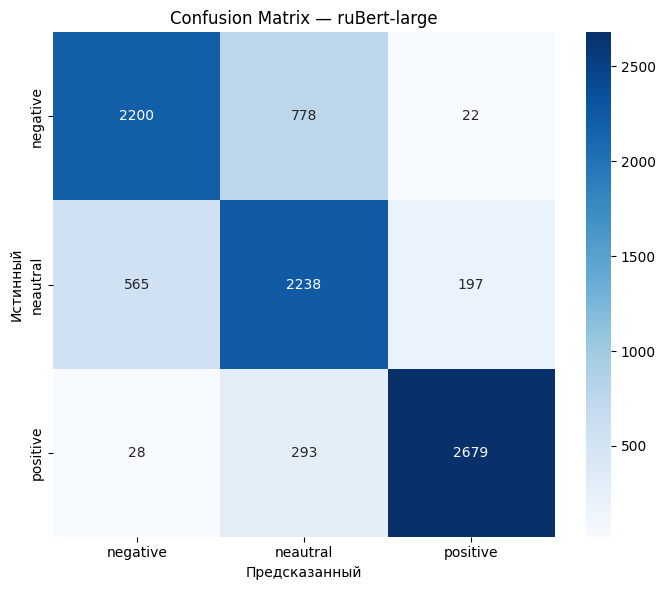

In [25]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — ruBert-large")
plt.ylabel("Истинный"); plt.xlabel("Предсказанный")
plt.tight_layout(); plt.show()

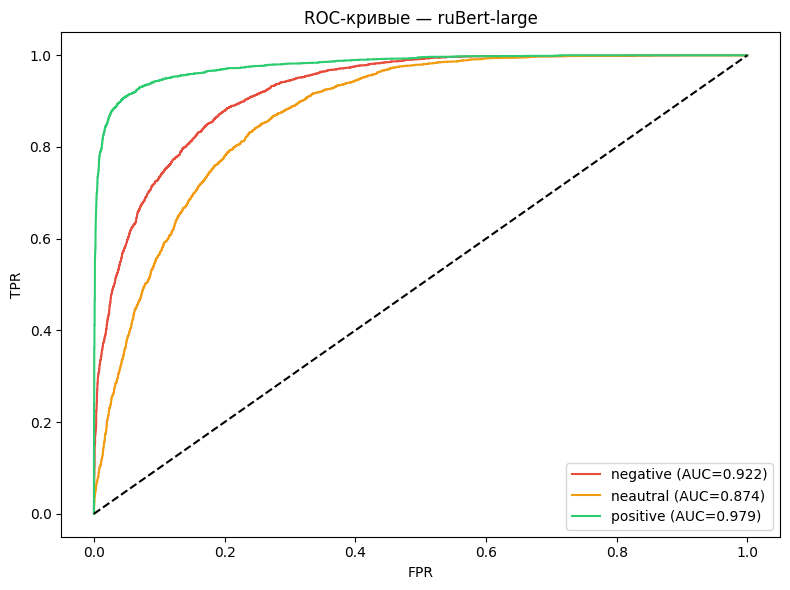

In [26]:
fig, ax = plt.subplots(figsize=(8,6))
for i,(cls,clr) in enumerate(zip(CLASS_NAMES,["#e74c3c","#f39c12","#2ecc71"])):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_probs[:,i])
    ax.plot(fpr, tpr, color=clr, label=f"{cls} (AUC={auc(fpr,tpr):.3f})")
ax.plot([0,1],[0,1],"k--")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC-кривые — ruBert-large"); ax.legend()
plt.tight_layout(); plt.show()

## 8. Время инференса и потребление памяти

In [27]:
model.eval()
ids0, mask0, _ = next(iter(test_loader))
# прогрев CUDA
for _ in range(3):
    with torch.inference_mode():
        model(input_ids=ids0.to(DEVICE), attention_mask=mask0.to(DEVICE))

# CUDA синхронизация перед замером
if DEVICE.type == "cuda": torch.cuda.synchronize()
t0 = time.perf_counter()
with torch.inference_mode():
    for ids, mask, _ in test_loader:
        model(input_ids=ids.to(DEVICE, non_blocking=True),
              attention_mask=mask.to(DEVICE, non_blocking=True))
if DEVICE.type == "cuda": torch.cuda.synchronize()

elapsed = time.perf_counter() - t0
ms_per  = elapsed / len(test_ds) * 1000
sps     = len(test_ds) / elapsed
print(f"Всего: {elapsed:.2f}с | Пример: {ms_per:.3f}мс | Скорость: {sps:.1f} примеров/с")

Всего: 122.99с | Пример: 13.665мс | Скорость: 73.2 примеров/с


In [28]:
proc   = psutil.Process(os.getpid())
ram_mb = proc.memory_info().rss / 1024**2
w_mb   = sum(p.numel()*p.element_size() for p in model.parameters()) / 1024**2
print(f"RAM процесса  : {ram_mb:.1f} МБ")
print(f"Размер весов  : {w_mb:.1f} МБ")
if DEVICE.type == "cuda":
    vram_mb = torch.cuda.memory_allocated() / 1024**2
    vram_reserved = torch.cuda.memory_reserved() / 1024**2
    print(f"VRAM выделено : {vram_mb:.1f} МБ")
    print(f"VRAM зарезерв.: {vram_reserved:.1f} МБ")

RAM процесса  : 4044.6 МБ
Размер весов  : 1628.5 МБ
VRAM выделено : 6533.3 МБ
VRAM зарезерв.: 8186.0 МБ


## 9. Итоговая таблица

In [29]:
summary = pd.DataFrame([
    ("Модель",              MODEL_NAME),
    ("Параметры (M)",       f"{total_params/1e6:.1f}"),
    ("Accuracy",            f"{acc:.4f}"),
    ("F1-macro",            f"{f1:.4f}"),
    ("Precision-macro",     f"{prec:.4f}"),
    ("Recall-macro",        f"{rec:.4f}"),
    ("ROC-AUC macro-OvR",   f"{roc:.4f}"),
    ("Время/пример (мс)",   f"{ms_per:.3f}"),
    ("Примеров/сек",        f"{sps:.1f}"),
    ("RAM процесса (МБ)",   f"{ram_mb:.1f}"),
    ("Размер весов (МБ)",   f"{w_mb:.1f}"),
], columns=["Метрика", "Значение"])
display(summary)

,Метрика,Значение
0,Модель,ai-forever/ruBert-large
1,Параметры (M),426.9
2,Accuracy,0.7908
3,F1-macro,0.7925
4,Precision-macro,0.7962
5,Recall-macro,0.7908
6,ROC-AUC macro-OvR,0.9250
7,Время/пример (мс),13.665
8,Примеров/сек,73.2
9,RAM процесса (МБ),4044.6
